In [1]:
all = [var for var in globals() if var[0] != '_']
for var in all:
    del globals()[var]
del all, var
# This script clears all global variables except those starting with an underscore.

In [5]:
import numpy as np
import scipy.optimize
import matplotlib.pyplot as plt
import heat_equation_2D_for_students
import module_opt_AD as modopt

/home/cykwonlab/MECH579_FinalProject/MECH579_proj/module_opt_AD.py:1150: SyntaxWarning: invalid escape sequence '\:'
  f (callable) : objective function(output \: single scalar)


In [ ]:
eta_trg = .5
eta_integral = lambda v : (-2/3000*v**3 + 8/200*v**2 - eta_trg*v)
eta_integral_torch = lambda v : eta_integral(v)
v_opt = modopt.quasi_newton_bfgs(f=eta_integral, f_torch=eta_integral_torch, x0=np.array([5.0]), tol=1e-6)

print("Optimal v:", v_opt[0][-1][0])

Since ||grad(x0)|| = 0.14999999999999997 > 1e-06, x0 : [5.] is not an optimum point. Optimization begins !
α* satisfying strong Wolfe's condition !
BFGS
f_1 : [-1.62565133]
‖∇f(x_1)‖ : 0.13218000000000002
‖∆x_1‖ : 0.2999999999999998
recent alpha : 2

α* satisfying strong Wolfe's condition !
BFGS
f_2 : [-1.78154973]
‖∇f(x_2)‖ : 0.01123864911743662
‖∆x_2‖ : 2.2252525252525315
recent alpha : 1

α* satisfying strong Wolfe's condition !
BFGS
f_3 : [-1.78281276]
‖∇f(x_3)‖ : 0.0010058166721532424
‖∆x_3‖ : 0.20678479400554295
recent alpha : 1

α* satisfying strong Wolfe's condition !
BFGS
f_4 : [-1.78282308]
‖∇f(x_4)‖ : 9.232268178088754e-06
‖∆x_4‖ : 0.02032551539084526
recent alpha : 1

α* satisfying strong Wolfe's condition !
BFGS
f_5 : [-1.78282308]
‖∇f(x_5)‖ : 7.725243889034061e-09
‖∆x_5‖ : 0.00018829374431028612
recent alpha : 1

α* satisfying strong Wolfe's condition !
BFGS
f_6 : [-1.78282308]
‖∇f(x_6)‖ : 5.939693181744587e-14
‖∆x_6‖ : 1.5768966665774542e-07
recent alpha : 1

α* not sati

Since ||grad(x0)|| = 0.34900000000000003 > 1e-06, x0 : [5.] is not an optimum point. Optimization begins !
α* satisfying strong Wolfe's condition !
BFGS
f_1 : [0.6829075]
‖∇f(x_1)‖ : 0.30614559199999997
‖∆x_1‖ : 0.6980000000000004
recent alpha : 2

α* satisfying strong Wolfe's condition !
BFGS
f_2 : [0.01963478]
‖∇f(x_2)‖ : 0.056689585097233056
‖∆x_2‖ : 4.986409407779003
recent alpha : 1

α* satisfying strong Wolfe's condition !
BFGS
f_3 : [0.00026326]
‖∇f(x_3)‖ : 0.006555689568304999
‖∆x_3‖ : 0.7790795884605726
recent alpha : 1

α* satisfying strong Wolfe's condition !
BFGS
f_4 : [-6.17174351e-06]
‖∇f(x_4)‖ : 0.00011278702483343392
‖∆x_4‖ : 0.0807555024143696
recent alpha : 1

α* satisfying strong Wolfe's condition !
BFGS
f_5 : [-6.25130236e-06]
‖∇f(x_5)‖ : 2.3232109130207444e-07
‖∆x_5‖ : 0.0014136754040265636
recent alpha : 1

α* satisfying strong Wolfe's condition !
BFGS
f_6 : [-6.25130269e-06]
‖∇f(x_6)‖ : 8.199202265581302e-12
‖∆x_6‖ : 2.9059326960637066e-06
recent alpha : 1

α* sa

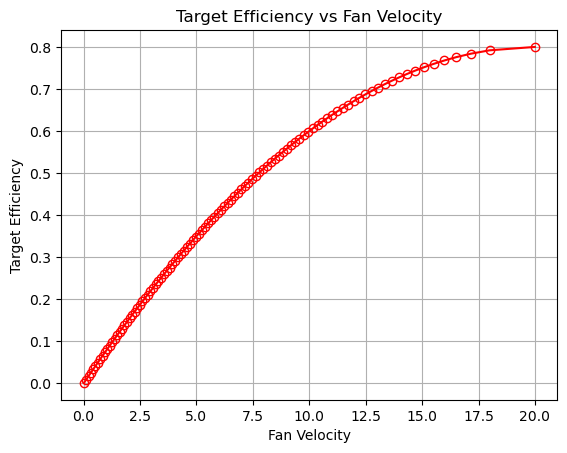

In [45]:
list_v_eta_trg = []
for eta_trg in np.linspace(0.001, 0.8, 100):
    eta_integral = lambda v : (-2/3000*v**3 + 8/200*v**2 - eta_trg*v)
    eta_integral_torch = lambda v : eta_integral(v)
    v_opt = modopt.quasi_newton_bfgs(f=eta_integral, f_torch=eta_integral_torch, x0=np.array([5.0]), tol=1e-6)
    list_v_eta_trg.append(v_opt[0][-1][0])
plt.plot(list_v_eta_trg, np.linspace(0.001, 0.8, 100), 'r-o', markerfacecolor='None', markeredgecolor='red') 
plt.xlabel('Fan Velocity')
plt.ylabel('Target Efficiency')
plt.title('Target Efficiency vs Fan Velocity')
plt.grid()
plt.show()

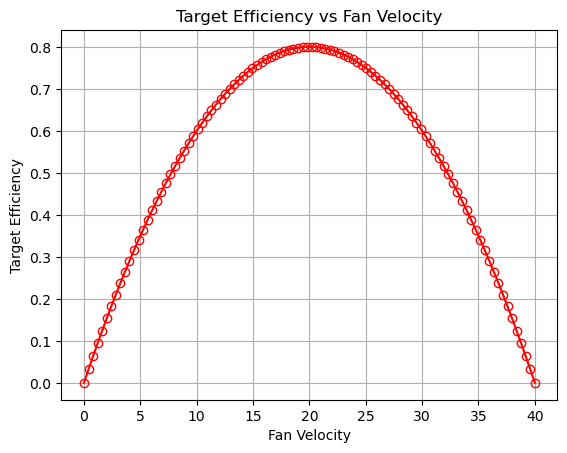

In [50]:
v_test = np.linspace(0.001, 40.0, 100)
eta = lambda v_test : -2/1000*v_test**2 + 8/100*v_test
plt.plot(v_test, eta(v_test), 'r-o', markerfacecolor='None', markeredgecolor='red') 
plt.xlabel('Fan Velocity')
plt.ylabel('Target Efficiency')
plt.title('Target Efficiency vs Fan Velocity')
plt.grid()
plt.show()

In [ ]:
w1 = .2 # weight for 1st objective
w2 = 1 - w1 # weight for 2nd objective
v = 7.75 # initial try for fan velocity

In [53]:
cpu_x = .04
cpu_y = .04
h = cpu_x*.025
n_x = 25
n_y = n_x
k_si = 148 # thermal conductivity of the material : Silicon [W/mK]
rho_si = 2323 # density of the material : Silicon [kg/m3]
c_si = 19.789 / 28.085 * 1000 # specific heat capacity of the material : Silicon [kJ/kgK]
CFL = 0.5 # CFL number for stability condition

def initial_condition(x: np.ndarray, y: np.ndarray) -> np.ndarray:
        r, c = x.shape
        u = np.zeros([r, c])
        ## Cosine Case
        u = 70 * np.sin(x * np.pi / cpu_x) * np.sin(y * np.pi / cpu_y) + 293
        return u

def heat_generation_function(x: np.ndarray, y: np.ndarray, a: float, b: float, c: float) -> np.ndarray:
        return a * x + b * y + c



heat_eqn2d = heat_equation_2D_for_students.HeatEquation2D(x=cpu_x, y=cpu_y, height=h, n_x=n_x, n_y=n_y, k=k_si, rho=rho_si, cp=c_si, 
                                                          CFL=CFL, init_condition = initial_condition)

In [54]:
x_axis = np.linspace(0, cpu_x, n_x)
y_axis = np.linspace(0, cpu_y, n_y)
X, Y = np.meshgrid(x_axis, y_axis)